# Class 03: Multicollinearity and overfitting
**_Does multicollinearity lead to overfitting?_**

<sub>The content for this practical has been adapted from:

<sub>https://machinelearningmastery.com/detecting-and-overcoming-perfect-multicollinearity-in-large-datasets/

<sub>https://stats.stackexchange.com/questions/361247/multicollinearity-and-predictive-performance</sub>

Collinearity refers to a situation where one variable can be expressed as a linear combination of other variables. As a result, the variables are not independent. While predictive performance is often the primary concern in forecasting tasks, collinearity can undermine the interpretability of a model. This is especially problematic in regression models, where coefficients are used to draw substantive conclusions about the relationship between predictors and the target variable.

We will explore this issue using the Ames Housing dataset.

## Import required libraries

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LassoCV
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.pipeline import Pipeline

## Load data

In [42]:
# Load the dataset
Ames = pd.read_csv('../data/raw/ames_housing.csv')

Documentation on the data you can find here: https://jse.amstat.org/v19n3/decock/DataDocumentation.txt

## Correlation plot

**TASK**
Make a correlation plot of the dataset.

In [43]:
# Add your code here

## Features and multicollinearity

As an initial check for strong multicollinearity, we compare the number of features with the matrix rank. The rank of a matrix is the maximum number of linearly independent rows or columns it contains. If the rank is lower than the number of features, at least one feature is a linear combination of others, indicating a perfect multicollinearity.

In [45]:
# Select numerical columns without missing values
numerical_data = Ames.select_dtypes(include=[np.number]).dropna(axis=1)
 
# Calculate the matrix rank
rank = np.linalg.matrix_rank(numerical_data.values)
 
# Number of features
num_features = numerical_data.shape[1]
 
# Print the rank and the number of features
print(f"Numerical features without missing values: {num_features}")
print(f"Rank: {rank}")

Numerical features without missing values: 28
Rank: 27


Our preliminary results show that the Ames Housing dataset has multicollinearity, with 28 features but only a rank of 27. Besides a few strong correlations, the correlation plot does not show any features which are perfectly correlated. However based on the rank we know that at least one feature is a linear combination of some other features.
To address this, let’s identify the redundant features using a function. This approach helps make informed decisions about feature selection or modifications to enhance model reliability and interpretability.

In [46]:
# From https://machinelearningmastery.com/detecting-and-overcoming-perfect-multicollinearity-in-large-datasets/

def find_redundant_features(data):
    """
    Identifies and returns redundant features in a dataset based on matrix rank.
    A feature is considered redundant if removing it does not decrease the rank of the dataset,
    indicating that it can be expressed as a linear combination of other features.

    Parameters:
        data (DataFrame): The numerical dataset to analyze.

    Returns:
        list: A list of redundant feature names.
    """

    # Calculate the matrix rank of the original dataset
    original_rank = np.linalg.matrix_rank(data)
    redundant_features = []

    for column in data.columns:
        # Create a new dataset without this column
        temp_data = data.drop(column, axis=1)
        # Calculate the rank of the new dataset
        temp_rank = np.linalg.matrix_rank(temp_data)

        # If the rank does not decrease, the removed column is redundant
        if temp_rank == original_rank:
            redundant_features.append(column)

    return redundant_features


numerical_data = Ames.select_dtypes(include=[np.number]).dropna(axis=1)
redundant_features = find_redundant_features(numerical_data)
print("Redundant features:", redundant_features)

Redundant features: ['1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area']


**TASK**
Can you check and explain how these variables are related?

In [47]:
# Add your code here

Having established the redundancy of Gr Liv Area through matrix rank analysis, we now aim to visualize the effects of multicollinearity on the regression model’s stability and predictive power. For ease, we will limit the number of features (see below).

First we assess the relationship between the features and the target variable.

In [49]:
features = ['Gr Liv Area', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF']

**TASK**
Make some basic exploration plot to study the relationship between the features and the target variables.

In [50]:
# Add your code here

## Validation and training data

In general, training data should be representative of future test data and we should avoid any extrapolation of our model. However, in the following example, besides a normal test split, we intentionally construct a non-representative training set (test_extrapolation) in order to assess its impact.

In [52]:
test_extrapolation = Ames[Ames['SalePrice'] > 500000]
train, test = train_test_split(Ames[Ames['SalePrice'] <= 500000], test_size=0.2, random_state=42)

First we train a LinearRegression model with a 5 fold CV and plot the coefficients and performance. For the CV a manual loop has been used.

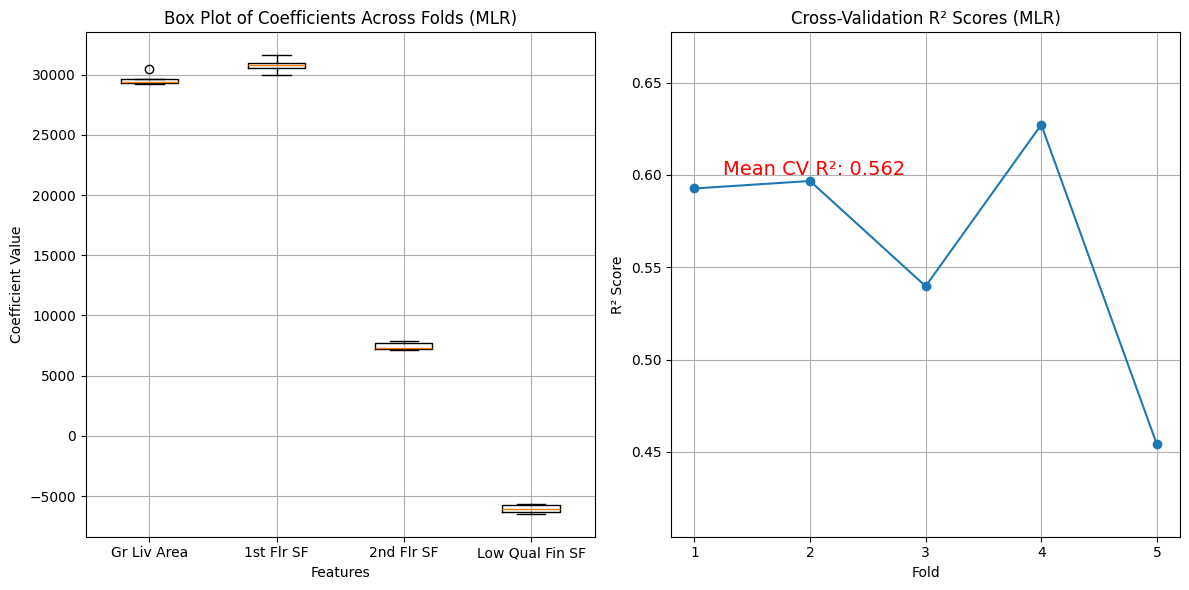

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[29585.5 ,30764.88, 7430.45,-6046.85]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.785e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](4,)","[63.8 ,54.25,48.02, 0. ]"


In [53]:
X = train[features]
y = train['SalePrice']

# Initialize a K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=1)

# Collect coefficients and CV scores
coefficients = []
cv_scores = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Initialize and fit the linear regression model
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)
    coefficients.append(model.coef_)

    # Calculate R^2 score using the model's score method
    score = model.score(X_test_scaled, y_test)
    # print(score)
    cv_scores.append(score)

# Plotting the coefficients
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.boxplot(np.array(coefficients), tick_labels=features)
plt.title('Box Plot of Coefficients Across Folds (MLR)')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.grid(True)

# Plotting the CV scores
plt.subplot(1, 2, 2)
plt.plot(range(1, 6), cv_scores, marker='o', linestyle='-')  # Adjusted x-axis to start from 1
plt.title('Cross-Validation R² Scores (MLR)')
plt.xlabel('Fold')
plt.xticks(range(1, 6))  # Set x-ticks to match fold numbers
plt.ylabel('R² Score')
plt.ylim(min(cv_scores) - 0.05, max(cv_scores) + 0.05)  # Dynamically adjust y-axis limits
plt.grid(True)

# Annotate mean R² score
mean_r2 = np.mean(cv_scores)
plt.annotate(f'Mean CV R²: {mean_r2:.3f}', xy=(1.25, 0.60), color='red', fontsize=14),

plt.tight_layout()
plt.show()

# Refit the model on all training data

model_full = LinearRegression()

# Scale the features
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

model_full.fit(X_scaled, y)

**TASK**
Can you check the VIF for the training dataset?

In [54]:
# Add your code here

All the variables do have an (important) coefficient, however this model could be made more simple since there is 1 redundant variable. Lasso regression can be a robust solution. Unlike multiple linear regression, Lasso can penalize the coefficients’ size and, crucially, set some coefficients to zero, effectively reducing the number of features in the model. This feature selection is particularly beneficial in mitigating multicollinearity. 

Ordinary Least Squares regression chooses the beta coefficients that minimize the residual sum of squares (RSS), which is the difference between the observed Y's and the estimated Y's.

The LASSO is an extension of OLS, which adds a penalty to the RSS equal to the sum of the absolute values of the non-intercept beta coefficients multiplied by parameter λ that slows or accelerates the penalty. E.g., if λ is less than 1, it slows the penalty and if it is above 1 it accelerates the penalty.


Let’s apply Lasso to our previous example to demonstrate this.


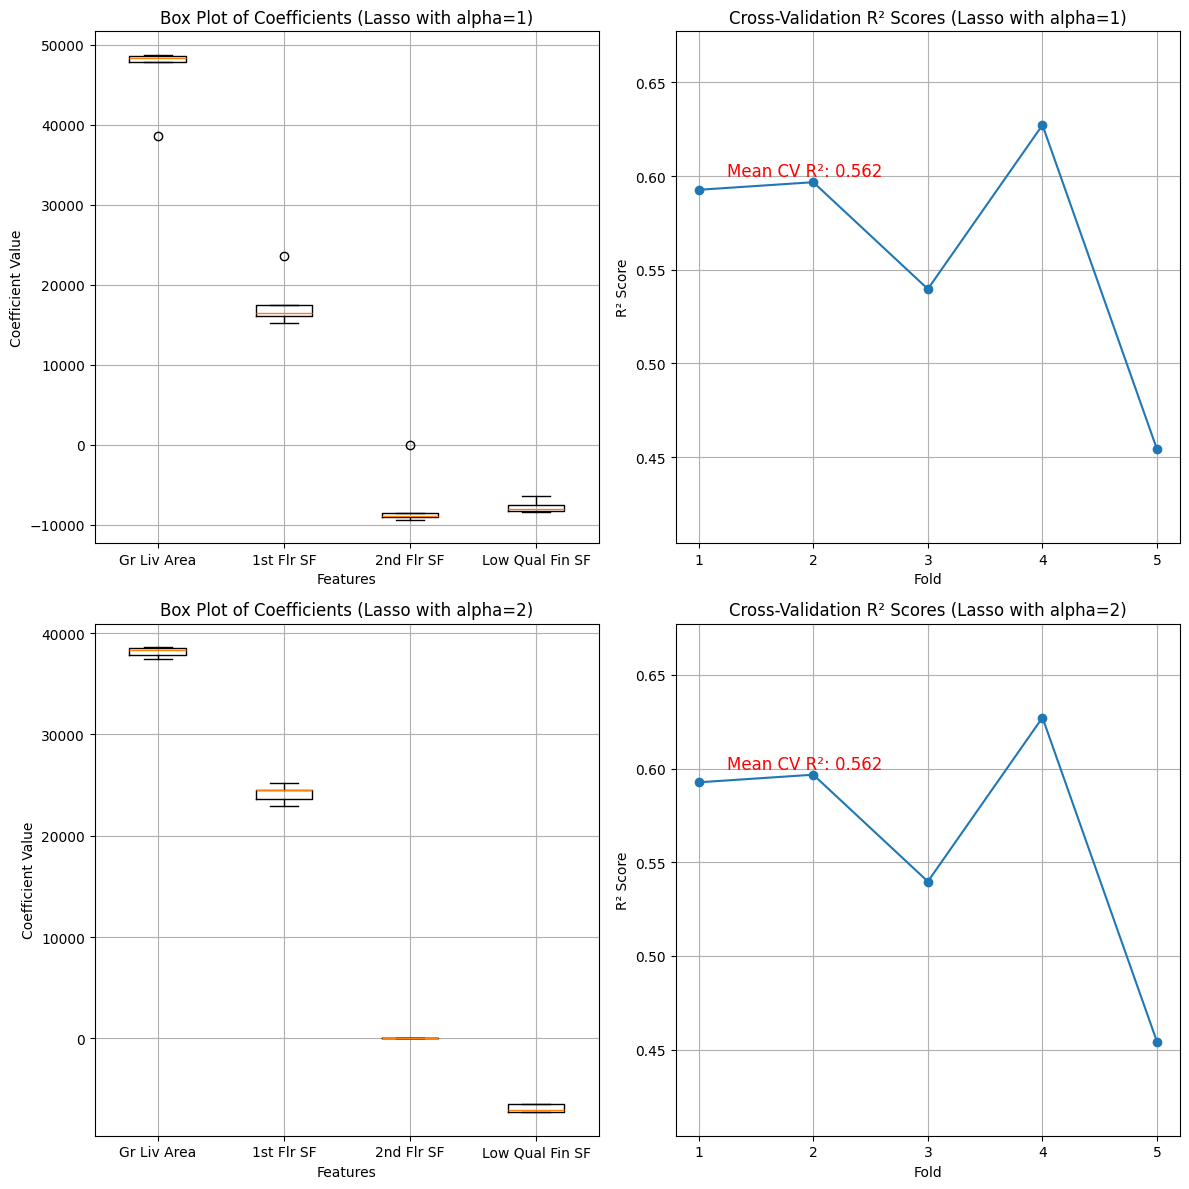

In [56]:
# Initialize a K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=1)

# Prepare to collect results
results = {}

for alpha in [1, 2]:  # Loop through both alpha values
    coefficients = []
    cv_scores = []

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Initialize and fit the Lasso regression model
        lasso_model = Lasso(alpha=alpha, max_iter=100000)
        lasso_model.fit(X_train_scaled, y_train)
        coefficients.append(lasso_model.coef_)

        # Calculate R^2 score using the model's score method
        score = lasso_model.score(X_test_scaled, y_test)
        cv_scores.append(score)

    results[alpha] = (coefficients, cv_scores)

# Plotting the results
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))
alphas = [1, 2]

for i, alpha in enumerate(alphas):
    coefficients, cv_scores = results[alpha]

    # Plotting the coefficients
    axes[i, 0].boxplot(np.array(coefficients), tick_labels=features)
    axes[i, 0].set_title(f'Box Plot of Coefficients (Lasso with alpha={alpha})')
    axes[i, 0].set_xlabel('Features')
    axes[i, 0].set_ylabel('Coefficient Value')
    axes[i, 0].grid(True)

    # Plotting the CV scores
    axes[i, 1].plot(range(1, 6), cv_scores, marker='o', linestyle='-')
    axes[i, 1].set_title(f'Cross-Validation R² Scores (Lasso with alpha={alpha})')
    axes[i, 1].set_xlabel('Fold')
    axes[i, 1].set_xticks(range(1, 6))
    axes[i, 1].set_ylabel('R² Score')
    axes[i, 1].set_ylim(min(cv_scores) - 0.05, max(cv_scores) + 0.05)
    axes[i, 1].grid(True)
    mean_r2 = np.mean(cv_scores)
    axes[i, 1].annotate(f'Mean CV R²: {mean_r2:.3f}', xy=(1.25, 0.60), color='red', fontsize=12)

plt.tight_layout()
plt.show()

The box plots on the left show that as alpha increases, the spread and magnitude of the coefficients decrease, indicating more stable estimates. Notably, the coefficient for ‘2nd Flr SF’ begins to approach zero as alpha is set to 1 and is virtually zero when alpha increases to 2. This trend suggests that 2nd Flr SF contributes minimally to the model as the regularization strength is heightened, indicating that it may be redundant or collinear with other features in the model. This stabilization is a direct result of Lasso’s ability to reduce the influence of less important features, which are likely contributing to multicollinearity.

The fact that 2nd Flr SF can be removed with minimal impact on the model’s predictability underscores the efficiency of Lasso in identifying and eliminating unnecessary predictors. Importantly, the overall predictability of the model remains unchanged even as this feature is effectively zeroed out, demonstrating the robustness of Lasso in maintaining model performance while simplifying its complexity.

Following the insights gained from the Lasso regression, we have refined our model by removing 2nd Flr SF, a feature identified as contributing minimally to the predictive power. This section evaluates the performance and stability of the coefficients in the revised model, using only ['Gr Liv Area', '1st Flr SF', 'Low Qual Fin SF'].

**TASK**
Fit a new LinearRegression model only using the relevant features. Evaluate again the effect of removing 1 variable on the model coefficients and performance by a 5 fold CV. After CV refit the model on the full training data and assign it to "model_reduced".

In [57]:
# Add your code here

The model has been succesfully reduced, maintaining the predictive performance of the model.

# Test data

We evaluated the different models using cross-validation. However, given the variability observed across the CV folds, the model is not yet very stable. We will now assess its performance on a held-out test set that has not been used during training or validation.

**TASK**
Evaluate the full and reduced linear model on both test sets ("test" and "test_extrapolation").
Do you expect any differences in predictions when the model has been suffering from the multicollinearity or not?

In [43]:
# Add your code here

# Making it more complex

However what would happen if we generate more correlated features? Our dataset has quite some taining instances and we have a very limited of features used. We have more than 2000 instances for training.
Below we generate synthetic features which are correlated with the Gr Liv Area variable.

Generating new features

In [61]:
X_train_new = train[features].copy()
X_test_new = test[features].copy()
X_test_extrapolation_new = test_extrapolation[features].copy()

y_train = train["SalePrice"]
y_test = test["SalePrice"]
y_test_extrapolation = test_extrapolation["SalePrice"]

for i in range(2000):
    noise = np.random.normal(0.8, 1, size=train.shape[0])

    X_train_new[f"synthetic_feature_{i}"] = noise * X_train_new["Gr Liv Area"]

    noise = np.random.normal(0.8, 1, size=test.shape[0])

    X_test_new[f"synthetic_feature_{i}"] = noise * X_test_new["Gr Liv Area"]

    #noise = np.random.normal(0.8, 1, size=test_extrapolation.shape[0])

    #X_test_extrapolation_new[f"synthetic_feature_{i}"] = noise * X_test_extrapolation_new["Gr Liv Area"]


C:\Users\SH\AppData\Local\Temp\ipykernel_18944\4624736.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train_new[f"synthetic_feature_{i}"] = noise * X_train_new["Gr Liv Area"]
C:\Users\SH\AppData\Local\Temp\ipykernel_18944\4624736.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test_new[f"synthetic_feature_{i}"] = noise * X_test_new["Gr Liv Area"]


Making a corrleation matrix

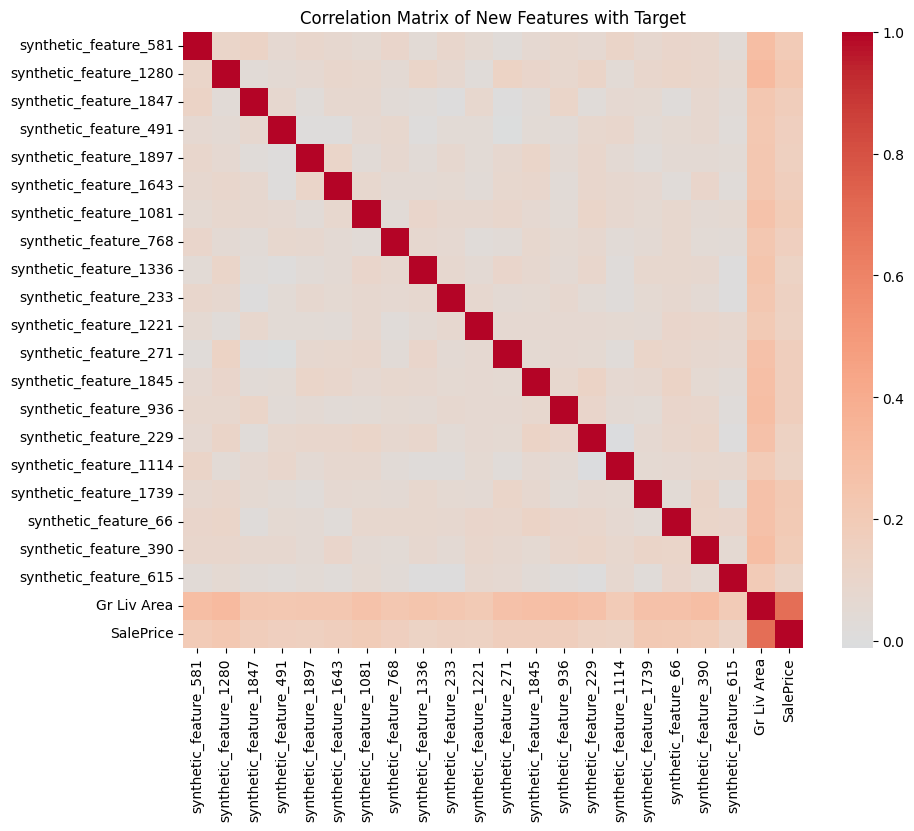

In [62]:
# Make heatmap of the correlation matrix for the new features (X_train_new) (we only select 20 random features) and with target variable (y_train)
train_sampled = X_train_new.copy()
train_sampled = train_sampled.sample(n=20, axis=1, random_state=42)
# Always keep Gr Liv Area"
train_sampled['Gr Liv Area'] = X_train_new['Gr Liv Area']
train_sampled[y_train.name] = y_train
plt.figure(figsize=(10, 8))
sns.heatmap(train_sampled.corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of New Features with Target')
plt.show()

Scale the features

In [63]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_new)
X_test_scaled = scaler.transform(X_test_new)
#X_test_extrapolation_scaled = scaler.transform(X_test_extrapolation_new)

First we fit again a linear model and evaluate performance on the train and test set.

Train R²: 0.9655
Test  R²: -1.5419


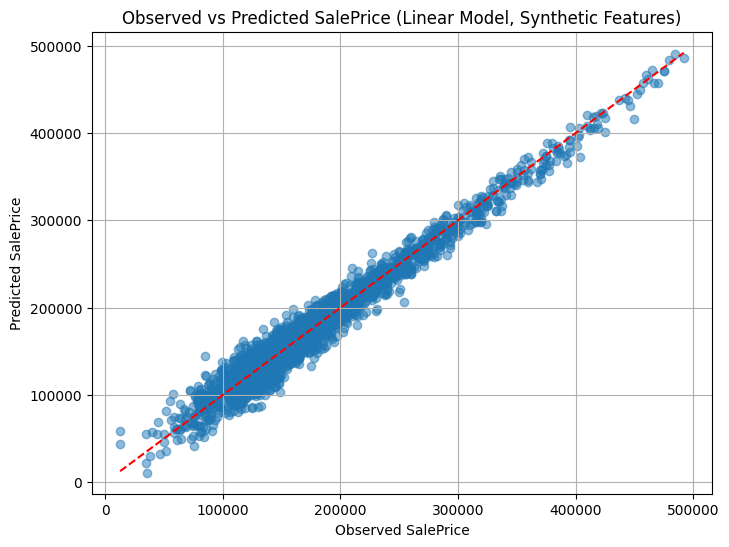

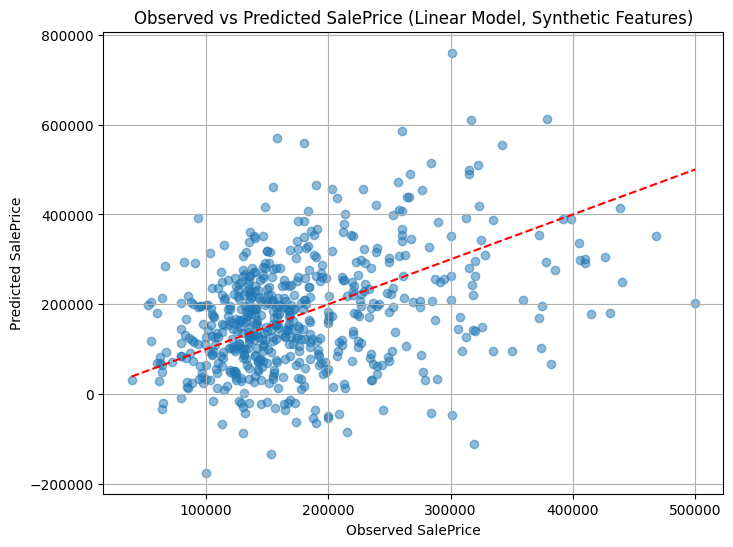

In [64]:
# Fit a linear model on the training data with synthetic features
model_synthetic = LinearRegression()
model_synthetic.fit(X_train_scaled, y_train)

# Predict on train and test
pred_train = model_synthetic.predict(X_train_scaled)
pred_test = model_synthetic.predict(X_test_scaled)

# Optional: print R² scores
print(f"Train R²: {model_synthetic.score(X_train_scaled, y_train):.4f}")
print(f"Test  R²: {model_synthetic.score(X_test_scaled, y_test):.4f}")

# Observed vs predicted plot (train)
plt.figure(figsize=(8, 6))
plt.scatter(y_train, pred_train, alpha=0.5)
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         color='red', linestyle='--')
plt.title('Observed vs Predicted SalePrice (Linear Model, Synthetic Features)')
plt.xlabel('Observed SalePrice')
plt.ylabel('Predicted SalePrice')
plt.grid(True)
plt.show()

# Observed vs predicted plot (test)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')
plt.title('Observed vs Predicted SalePrice (Linear Model, Synthetic Features)')
plt.xlabel('Observed SalePrice')
plt.ylabel('Predicted SalePrice')
plt.grid(True)
plt.show()

As shown above a linear model is indeed very susceptible to overfitting. Although the features do not contain any new relevant information op top of Gr Liv Area, it is very easy to get a perfect fit on training data with this high number on features. However on test data the model will clearly fail. This illustrates the need for doing cross-validation and have a clean test set. Moreover it also shows the importance of doing proper features selection.

Can we fix this problem easily with a Lasso regression?

Train R²: 0.9654
Test  R²: -1.3557


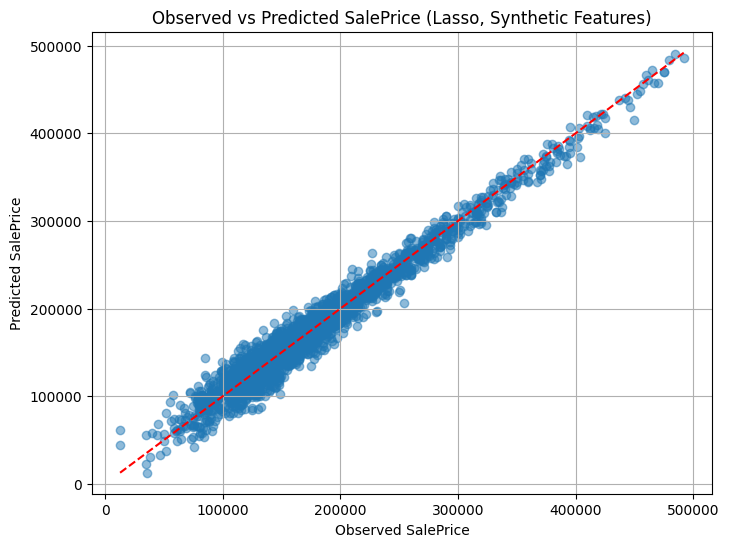

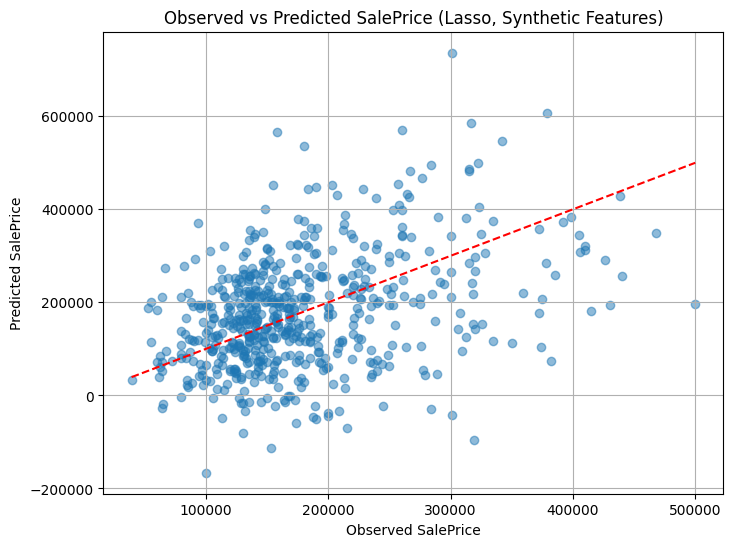

In [65]:
# Fit a Lasso model on the training data with synthetic features
lasso_model = Lasso(alpha=2, max_iter=20000)
lasso_model.fit(X_train_scaled, y_train)

# Predict on train and test
pred_train = lasso_model.predict(X_train_scaled)
pred_test = lasso_model.predict(X_test_scaled)

# Print R² scores
print(f"Train R²: {lasso_model.score(X_train_scaled, y_train):.4f}")
print(f"Test  R²: {lasso_model.score(X_test_scaled, y_test):.4f}")


# Observed vs predicted plot (train)
plt.figure(figsize=(8, 6))
plt.scatter(y_train, pred_train, alpha=0.5)
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         color='red', linestyle='--')
plt.title('Observed vs Predicted SalePrice (Lasso, Synthetic Features)')
plt.xlabel('Observed SalePrice')
plt.ylabel('Predicted SalePrice')
plt.grid(True)
plt.show()

# Observed vs predicted plot (test)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')
plt.title('Observed vs Predicted SalePrice (Lasso, Synthetic Features)')
plt.xlabel('Observed SalePrice')
plt.ylabel('Predicted SalePrice')
plt.grid(True)
plt.show()

Based on the output, the model heavily overfits. So the regularization does not work? We can still tune the regularization (alpha). Note it is important that we perform this tuning with a CV and keep our test data untouched. A big pitfall in machine learning is that we just try some alpha values in the code above. For exploration and didactic goals this is okay, but not in a predictive setting. 

**TASK**
Tune the apha in the lasso regression, make a grid with custom values (try to limit to e.g. +/- 20 values). For tuning use the LasssoCV() function. Since we will use CV, we will implement the scaling of the features in a pipeline. Evaluate on X_train_new and X_test_new.

In [ ]:
# Add your code here

# lasso_cv_model = Pipeline([

There is overfitting, you could try to expand the grid. However to finish we will evaluate the performance of a Random Forest model on this overload of variables.

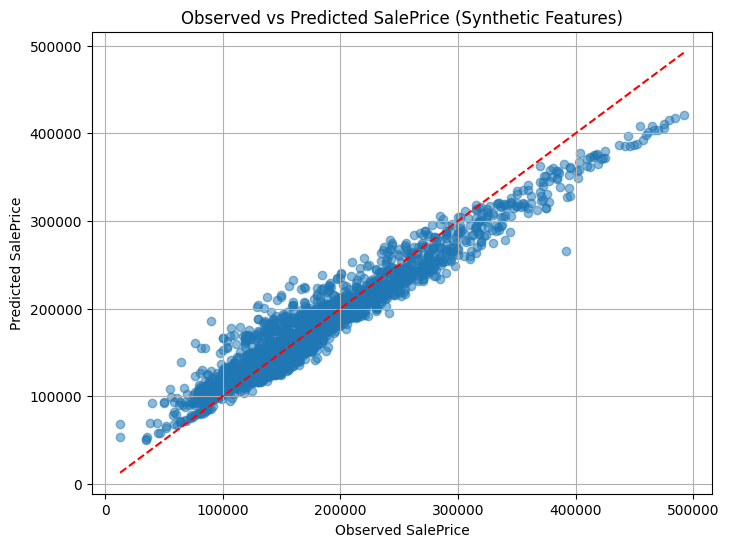

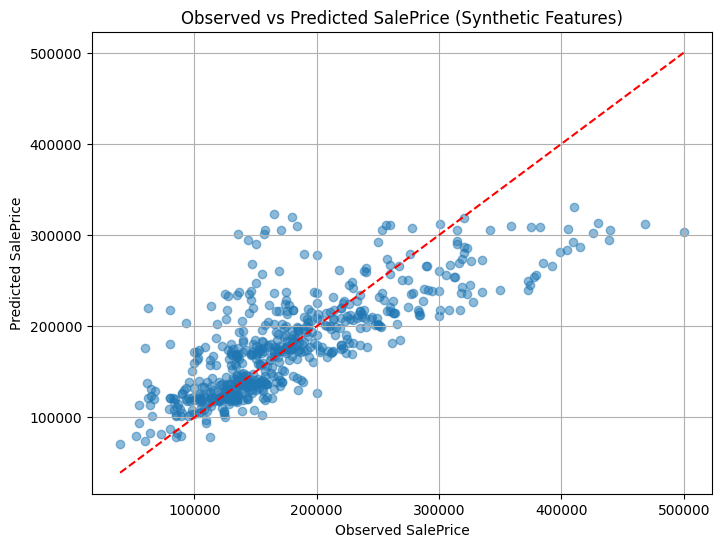

In [69]:
# Fit a random forest model on the training data with synthetic features
model_synthetic = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_split=5, min_samples_leaf=2, random_state=42)
model_synthetic.fit(X_train_scaled, y_train)

# Plot performance on train and test data
pred_train = model_synthetic.predict(X_train_scaled)
pred_test = model_synthetic.predict(X_test_scaled)

# Obs vs predicted plot for training data x_train_new and y_train_new
plt.figure(figsize=(8, 6))
plt.scatter(y_train, pred_train, alpha=0.5)
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         color='red', linestyle='--')  # Add a reference line for perfect predictions
plt.title('Observed vs Predicted SalePrice (Synthetic Features)')
plt.xlabel('Observed SalePrice')
plt.ylabel('Predicted SalePrice')
plt.grid(True)

# Apply the model to the test data and plot performance
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
            color='red', linestyle='--')  # Add a reference line for perfect predictions
plt.title('Observed vs Predicted SalePrice (Synthetic Features)')
plt.xlabel('Observed SalePrice')
plt.ylabel('Predicted SalePrice')
plt.grid(True)

In [70]:
# Print R² scores
print(f"Train R²: {model_synthetic.score(X_train_scaled, y_train):.4f}")
print(f"Test  R²: {model_synthetic.score(X_test_scaled, y_test):.4f}")

Train R²: 0.9180
Test  R²: 0.6048


The observed overfitting reflects the fundamental bias–variance trade-off in machine learning. This trade-off describes the relationship between model complexity, predictive accuracy, and the ability to generalize to unseen data. As a model becomes more complex, it gains greater flexibility to capture patterns in the training data, thereby reducing bias and improving training performance. However, increased complexity also makes the model more sensitive to random fluctuations and noise in the training data, leading to higher variance and potentially poorer performance on new data.

In general, models with a larger number of tunable parameters can achieve a closer fit to the training data, but their predictions may vary substantially when trained on different samples. Consequently, while reducing bias often improves training accuracy, it can come at the cost of increased variance and reduced generalizability.

In this case, the Random Forest model exhibits some signs of overfitting, as indicated by the R² values. Nevertheless, its strong performance on the test set suggests that the increase in variance remains limited and that the model retains a good ability to generalize. Therefore, accepting a certain degree of overfitting may be justified if it leads to improved predictive performance on unseen data. This trade-off must be  balanced against other considerations, including model interpretability, computational efficiency, and robustness.
